# Individual Assignment M2: MC and Brute Force Method
**OPIM 5641: Business Decision Modeling - University of Connecticut**

-------------------------------------------------------------------------
* Matthew Koh
* mek12008

**Directions:**
Adopted from Chapter 9, Problem 5 from Powell using the brute force method.

**5. Planning Automobile Production.** The Auto Company
of America (ACA) produces four types of cars: subcompact,
compact, intermediate, and luxury. ACA also produces trucks
and vans. Vendor capacities limit total production capacity to
at most 1.2 million vehicles per year. Subcompacts and com-
pacts are built together in a facility with a total annual capacity
of 620,000 cars. Intermediate and luxury cars are produced in
another facility with capacity of 400,000; and the truck/van
facility has a capacity of 275,000. ACA’s marketing strategy
requires that subcompacts and compacts must constitute at
least half of the product mix for the four car types. The
Corporate Average Fuel Economy (CAFE) standards in the
Energy Policy and Conservation Act require an average fleet
fuel economy of at least 27 mpg.

Profit margins, market potential, and fuel efficiencies are
summarized as follows:

Type | Profit Margin (USD/vehicle) |Market Potential (sales in ‘000) | Fuel Economy (mpg)
---| ---| ---| ---
Subcompact| 50| 600| 40
Compact| 225| 400| 34
Intermediate| 250| 300| 15
Luxury| 500| 225| 12
Truck| 400| 325| 20
Van| 200| 100| 25


***To simplify the problem, use a step size of 25 in your `range()` functions!***

1. What is the optimal profit for ACA?
2. Re-run the problem 10,000 times using a Monte Carlo simulation (for loop) but instead the total number of vehicles being 1.2 million, use a random number between 1 million and 1.5 million. Then plot the distribution of the profit! If you could solve Question 1, this question should only take you 10 or 15 more minutes to code up and solve!

You may work with your fellow classmates, but you need to complete the assignment on your own. I expect different headers and COMMENTS (comments are the key to showing that you really know your stuff - without comments, your code is useless to me).

**Rubric:**
* Full credit (100): Code along with the 'furniture/ brute force' example from class as your guide and add LOTS of original, useful comments. Nice headers and text cells included in the notebook.
* Half credit (50): The problem has been coded up, but the solution is wrong (bad code) or the comments are mediocre or directly copied. Nice headers and text cells included in the notebook.
* No credit (0): Bad code and bad comments, or good code and no comments (yes, we are that serious about comments in this class!) Poorly laid out notebook.



In [32]:
# In this notebook, I will want to check the amount of time spent in the execution of each cell, so I need to install an additional package
!pip install ipython-autotime
%load_ext autotime

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
time: 4.41 s (started: 2026-10-05 01:28:44 +00:00)


In [33]:
# subcompacts + compacts + intermediates + luxurys + trucks + vans <= 1,200,000
# subcompacts + compacts <= 620,000
# intermediates + luxuries <= 400,000
# trucks + vans <= 275,000

# assuming car types excludes trucks and vans:
# subcompacts + compacts >= 50%(s+c+i+l)

# energy conservation act:
# 40 s + 34 c + 15 i + 12 l + 20 t + 25 v >= 27 * total_vehicles

# total_mpg / total_vehicles >= 27, total_vehicles can't equal zero in denominator, so
# total_mpg >= 27 * total_vehicles
# everything must be non negative


time: 398 µs (started: 2026-10-05 01:28:48 +00:00)


#### [**Here is my Github link for Assignment 2**](https://github.com/mkoh55/opim5641-work/tree/main/Assignment%202)

In [34]:
  # your code here - DOWNLOAD YOUR OWN COPY then complete the assignment

# list
# https://en.wikipedia.org/wiki/Array_data_structure
products = ["subcompact","compact","intermediate","luxury","truck","van"]

# ...dict?
# https://en.wikipedia.org/wiki/Associative_array
profit = {
  "subcompact": 50,
  "compact": 225,
  "intermediate": 250,
  "luxury": 500,
  "truck": 400,
  "van": 200
}
demand = {
  "subcompact": 600,
  "compact": 400,
  "intermediate": 300,
  "luxury": 225,
  "truck": 325,
  "van": 100
}
mpg = {
  "subcompact": 40,
  "compact": 34,
  "intermediate": 15,
  "luxury": 12,
  "truck": 20,
  "van": 25
}
capacity = {
    "total_vehicles": 1200,
    "pacts_facility": 620,
    "linterlux_facility": 400,
    "truckvans_facility": 275
}


time: 1.02 ms (started: 2026-10-05 01:28:48 +00:00)


not sure if intended but typing anything out immediately gives me complete dictionary autofill, the only things I typed were the following:

profit = { tab

demand = { tab

mpg = { tab

capacity = { tota tab

reminder: all units are currently in 1000's

Now build your model!

In [35]:
def simulate(vehicle_cap):
  best_profit = 0
  best_subcompacts = 0
  best_compacts = 0
  best_intermediates = 0
  best_luxurys = 0
  best_trucks = 0
  best_vans = 0
  product_mix_ratio = 0.5
  CAFE_legal_mpg = 27

  # python ranges go from 0 UP TO the index of the last element. this does not include last element, +1 includes it.
  for subcompacts in range(0,demand["subcompact"]+1,25):
    for compacts in range(0,demand["compact"]+1,25):
      for intermediates in range(0,demand["intermediate"]+1,25):
        for luxurys in range(0,demand["luxury"]+1,25):
          for trucks in range(0,demand["truck"]+1,25):
            for vans in range(0,demand["van"]+1,25):
              total_vehicles = subcompacts + compacts + intermediates + luxurys + trucks + vans
              pacts_facility = subcompacts + compacts
              linterlux_facility = intermediates + luxurys
              truckvans_facility = trucks + vans

              # subcompacts + compacts + intermediates + luxurys + trucks + vans <= 1,200,000
              # subcompacts + compacts <= 620,000
              # intermediates + luxuries <= 400,000
              # trucks + vans <= 275,000

              # assuming car types excludes trucks and vans:
              # subcompacts + compacts >= 50%(s+c+i+l)

              # energy conservation act:
              # 40 s + 34 c + 15 i + 12 l + 20 t + 25 v >= 27 * total_vehicles

              # total_mpg / total_vehicles >= 27, total_vehicles can't equal zero in denominator, so
              # total_mpg >= 27 * total_vehicles
              # everything is non negative

              total_mpg = (mpg["subcompact"]*subcompacts + mpg["compact"]*compacts + mpg["intermediate"]*intermediates + mpg["luxury"]*luxurys + mpg["truck"]*trucks + mpg["van"]*vans) # >= 27 * total_vehicles

              if (
                  total_vehicles <= vehicle_cap
                  and pacts_facility <= capacity["pacts_facility"]
                  and linterlux_facility <= capacity["linterlux_facility"]
                  and truckvans_facility <= capacity["truckvans_facility"]
                  and pacts_facility >= product_mix_ratio * (subcompacts + compacts + intermediates + luxurys) # trucks and vans not counted
                  and total_mpg >= CAFE_legal_mpg * total_vehicles):
                total_profit = profit["subcompact"]*subcompacts + profit["compact"]*compacts + profit["intermediate"]*intermediates + profit["luxury"]*luxurys + profit["truck"]*trucks + profit["van"]*vans
                if total_profit > best_profit:
                  best_profit = total_profit
                  best_subcompacts = subcompacts
                  best_compacts = compacts
                  best_intermediates = intermediates
                  best_luxurys = luxurys
                  best_trucks = trucks
                  best_vans = vans



  return {"best_profit" : best_profit,
          "best_subcompacts" : best_subcompacts,
          "best_compacts" : best_compacts,
          "best_intermediates" : best_intermediates,
          "best_luxurys" : best_luxurys,
          "best_trucks" : best_trucks,
          "best_vans" : best_vans}


tmp = simulate(capacity["total_vehicles"])
for x in tmp:
  if x == "best_profit": print("Maximum profit: $", tmp[x] * 1000) # unit for everything is assumed to be in the 1000's
  if x != "best_profit": print(x, ": ", tmp[x], "k vehicles")



Maximum profit: $ 322500000
best_subcompacts :  200 k vehicles
best_compacts :  400 k vehicles
best_intermediates :  0 k vehicles
best_luxurys :  225 k vehicles
best_trucks :  275 k vehicles
best_vans :  0 k vehicles
time: 8.37 s (started: 2026-10-05 01:28:49 +00:00)


Optimal profit for ACA is $322,500,000:
- 200k subcompacts,
- 400k compacts,
- 0 intermediates,
- 225k luxury,
- 275k trucks,
- 0 vans

Intermediate car demand got screwed at interlux facility, because 15mpg's lower pricepoint is less optimal than 12mpg's higher pricepoint. vans got screwed at truckvans facility. optimal to supply all luxury cars and no intermediates and all trucks and no vans

Zero intermediates and zero vans could hurt dealer relationships or brand coverage. just because we can drop a market doesn't always mean we should drop a market

  time: 8.37 s (started: 2026-10-05 01:28:49 +00:00)

In [36]:
best_by_capacity = {} # appending dict 10,000 monte carlo optimals
mincap = 1000 # 1   million
maxcap = 1500 # 1.5 million
stepwise = 25 # 25  thousand
for i in range(mincap, maxcap+1, stepwise):
  best_by_capacity[i] = simulate(i) # run the 6 for-loop brute force 10,000x and each time save that instance's optimal ACA profit in best_by_capacity dict

time: 1min 32s (started: 2026-10-05 01:28:57 +00:00)


stepwise from 1000 to 1500 in increments of 25 (21x):

  time: 1min 32s (started: 2026-10-05 01:28:57 +00:00)

In [37]:
import numpy as np
np.random.seed(5641)
sim_profits = []
for i in range(10000):
  monte_carlo_capacity = np.random.uniform(mincap,maxcap)
  # stepwise of 25(thousand) means that each draw is rounded down to the nearest multiple of 25k and its precomputed optimum is looked up
  # a simulation with a remainder of less than 25000 will not affect optimal profit decision and will default to the previous increment:
  capacity_rounded = int(monte_carlo_capacity - monte_carlo_capacity % stepwise)
  sim_profits.append(best_by_capacity[capacity_rounded]["best_profit"] * 1000) # unit for everything is assumed to be in the 1000's

time: 37 ms (started: 2026-10-05 01:30:30 +00:00)


10,000 simulations done with random capacities ranging between 1mil and 1.5mil rounded down to the nearest 21 optimal profit increment capacities of 25k between 1mil and 1.5mil:

  time: 37 ms (started: 2026-10-05 01:30:30 +00:00)

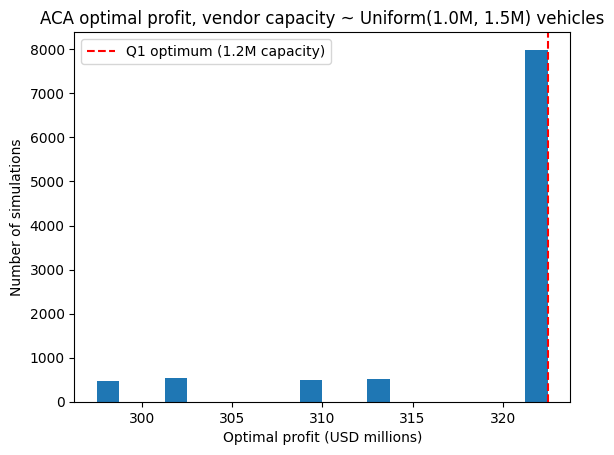

time: 205 ms (started: 2026-10-05 01:30:30 +00:00)


In [38]:
import matplotlib.pyplot as plt
sim_profits_millions = [p / 1e6 for p in sim_profits] # convert to millions

plt.hist(sim_profits_millions, bins=20)
plt.axvline(322.5, color="red", linestyle="--", label="Q1 optimum (1.2M capacity)") # red line is Q1's deterministic optimum
plt.xlabel("Optimal profit (USD millions)")
plt.ylabel("Number of simulations")
plt.title("ACA optimal profit, vendor capacity ~ Uniform(1.0M, 1.5M) vehicles")
plt.legend()
plt.show()

About 80% of draws land at $322.5M
Vendor capacity stops mattering above 1.1M vehicles

Took Dave 20 mins to code this whole thing up! How long did it take you?

2 hours to remember how to automate for loops with recursion

30 min to realize and stop because that wasn't the assignment

25 minutes driving

30 minutes of giving up and moving over jupyter notebook environment to google colab

5 minutes of pretending like clicking and dragging all of this into claude couldn't immediately do all of this work

3 hours of redoing it by hand to internalize logic and methodology

20 minutes helping other people understand how 25 stepwise cuts time and the 1000 unit incrementation using an analogy about KFC and meals priced at increments of $25

3 hours of checking work

Be careful with your indents and naming conventions and inequality signs... this is a TOUGH ASSIGNMENT and I am here to help you.